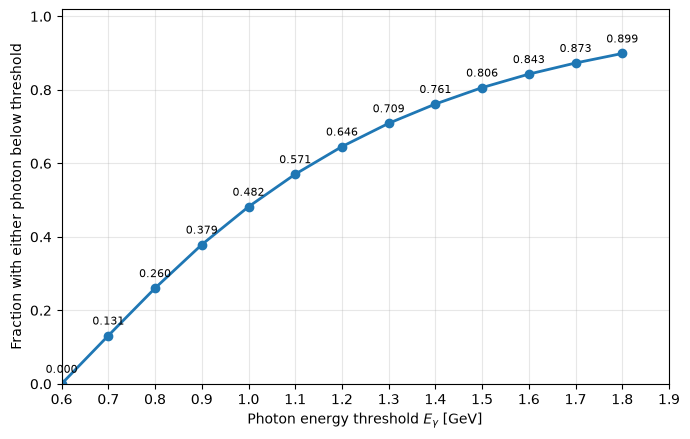

In [ ]:
# plot for the cumulative fraction of pi0 events with either photon below a given energy threshold, weighted by pi0_weight * scale * charge_frac

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

rootfile = Path(
    "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/"
    "output/KinC_x36_5_yaopeng_06gev/KinC_x36_5/root/combined_branches_LH2.root"
)
tree_name = "physics"

branches = [
    "mpi0_all",
    "pi0_weight",
    "scale",
    "charge_uC",
    "run_number",
    "cluster_e_1",
    "cluster_e_2",
]

with uproot.open(rootfile) as infile:
    arrays = infile[tree_name].arrays(branches, library="np")

mpi0_all = arrays["mpi0_all"].astype(float)
pi0_weight = arrays["pi0_weight"].astype(float)
scale = arrays["scale"].astype(float)
charge_uC = arrays["charge_uC"].astype(float)
run_number = arrays["run_number"]
cluster_e_1 = arrays["cluster_e_1"].astype(float)
cluster_e_2 = arrays["cluster_e_2"].astype(float)

# Match the workflow convention:
# charge_frac = charge_uC / total_charge_uC, with charge counted once per run.
positive_charge = np.isfinite(charge_uC) & (charge_uC > 0)
unique_runs, first_seen = np.unique(run_number[positive_charge], return_index=True)
run_charge = charge_uC[positive_charge][first_seen]
total_charge_uC = run_charge.sum()
if not np.isfinite(total_charge_uC) or total_charge_uC <= 0:
    raise ValueError("Invalid total charge; cannot compute charge_frac weights")

charge_frac = np.zeros_like(charge_uC, dtype=float)
run_lookup = np.searchsorted(unique_runs, run_number)
has_charge = run_lookup < unique_runs.size
has_charge[has_charge] &= unique_runs[run_lookup[has_charge]] == run_number[has_charge]
charge_frac[has_charge] = run_charge[run_lookup[has_charge]] / total_charge_uC

min_photon_energy = np.minimum(cluster_e_1, cluster_e_2)
signal_weight = pi0_weight * scale * charge_frac

valid = (
    np.isfinite(mpi0_all)
    & np.isfinite(cluster_e_1)
    & np.isfinite(cluster_e_2)
    & np.isfinite(signal_weight)
    & (signal_weight > 0)
)

energy_grid = np.round(np.arange(0.6, 1.8 + 0.05, 0.1), 1)
x_ticks = np.round(np.arange(0.6, 1.9 + 0.05, 0.1), 1)
normalization = signal_weight[valid].sum()
if normalization <= 0:
    raise ValueError("No positive weighted pi0 signal found")

cumulative_weight = np.array(
    [signal_weight[valid & (min_photon_energy <= energy)].sum() for energy in energy_grid]
)
cumulative_fraction = cumulative_weight / normalization

cdf = pd.DataFrame(
    {
        "photon_energy_threshold_GeV": energy_grid,
        "cumulative_weight": cumulative_weight,
        "cumulative_fraction": cumulative_fraction,
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cdf["photon_energy_threshold_GeV"], cdf["cumulative_fraction"], marker="o", linewidth=2)
for energy, fraction in zip(cdf["photon_energy_threshold_GeV"], cdf["cumulative_fraction"]):
    ax.annotate(
        f"{fraction:.3f}",
        (energy, fraction),
        textcoords="offset points",
        xytext=(0, 6),
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.set_xlabel(r"Photon energy threshold $E_{\gamma}$ [GeV]")
ax.set_ylabel(r"Fraction with either photon below threshold")
ax.set_xlim(energy_grid[0], 1.9)
ax.set_ylim(0.0, 1.02)
ax.set_xticks(x_ticks)
ax.grid(True, alpha=0.3)
fig.tight_layout()

# cdf


Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_mu_MeV_vs_run.png
Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_mu_MeV_vs_run.pdf
Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_sigma_MeV_vs_run.png
Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_sigma_MeV_vs_run.pdf
Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_signal_counts_vs_run.png
Wrote /work/hallc/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/output/plots_misc/pi0_energy_comparison/pi0_signal_counts_vs_run.pdf


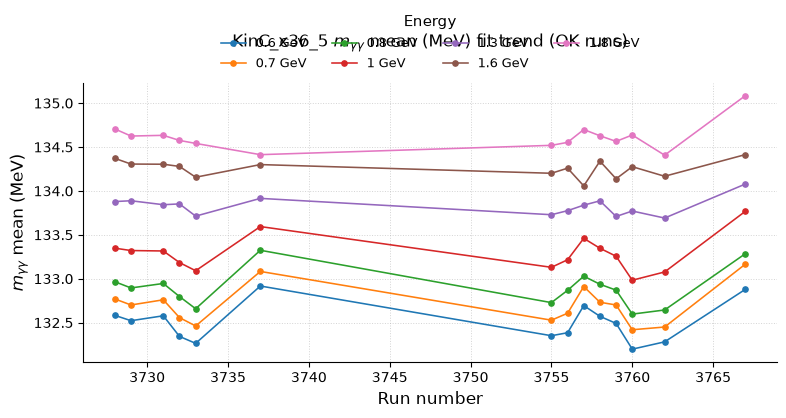

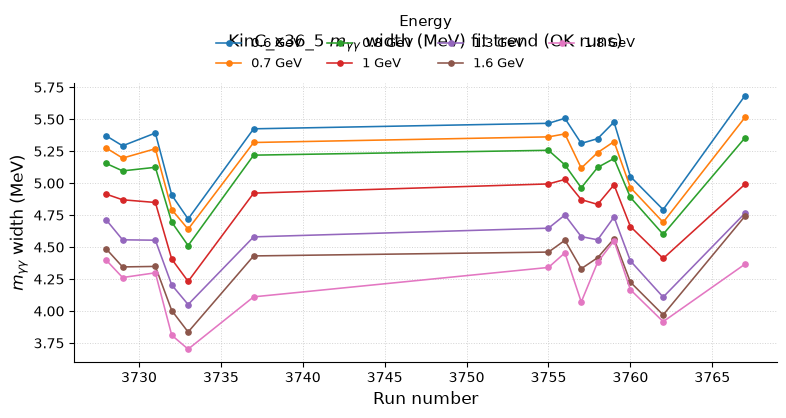

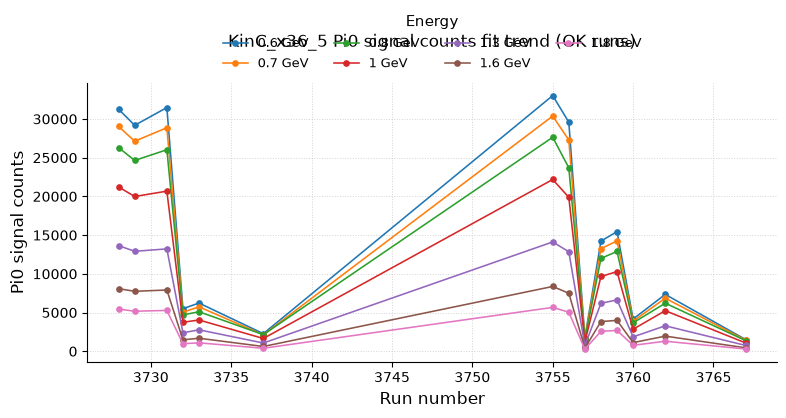

In [18]:
#!/usr/bin/env python3
"""Plot pi0 fit trends vs run number for several energy settings."""

from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(os.environ.get("TMPDIR", "/tmp")) / "matplotlib"),
)

import matplotlib.pyplot as plt
import pandas as pd


BASE_DIR = Path(
    "/work/hallc/nps/singhav/nps_analysis/pi0_analysis/"
    "root_analysis_env_main/output"
)
KINEMATIC = "KinC_x36_5"
DEFAULT_OUTDIR = BASE_DIR.parent / "output/plots_misc/pi0_energy_comparison"
METRICS = [
    ("pi0_mu_MeV", r"$m_{\gamma\gamma}$ mean (MeV)"),
    ("pi0_sigma_MeV", r"$m_{\gamma\gamma}$ width (MeV)"),
    ("pi0_signal_counts", "Pi0 signal counts"),
]


def energy_value(token: str) -> float:
    """Convert folder tokens like 06, 1, 13, 16 to 0.6, 1.0, 1.3, 1.6."""
    if "." in token:
        return float(token)
    if len(token) == 1:
        return float(token)
    return float(int(token)) / 10.0


def energy_label(token: str) -> str:
    return f"{energy_value(token):g} GeV"


def find_summary_files(base_dir: Path) -> list[tuple[float, str, Path]]:
    pattern = f"{KINEMATIC}_yaopeng_*gev/{KINEMATIC}/summary/summary_all_runs.csv"
    files: list[tuple[float, str, Path]] = []
    for path in base_dir.glob(pattern):
        match = re.search(r"_yaopeng_([^/]+)gev/", str(path))
        if not match:
            continue
        token = match.group(1)
        try:
            value = energy_value(token)
        except ValueError:
            continue
        files.append((value, energy_label(token), path))
    return sorted(files, key=lambda item: item[0])


def load_summary(path: Path, label: str, status: str) -> pd.DataFrame:
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = df.columns.str.strip()
    df["energy"] = label

    for col in ["run", *[name for name, _ in METRICS]]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["run"])
    if status.lower() != "all" and "run_status" in df.columns:
        df = df[df["run_status"].astype(str).str.strip() == status]
    return df.sort_values("run")


def plot_multipanel(data: list[pd.DataFrame], outdir: Path, status: str):
    plt.rcParams.update(
        {
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "legend.fontsize": 9,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "savefig.dpi": 300,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    colors = plt.get_cmap("tab10")
    figs = []
    axes = []

    for metric, ylabel in METRICS:
        fig, ax = plt.subplots(figsize=(8.0, 4.8))
        for idx, df in enumerate(data):
            good = df[["run", metric]].dropna()
            if good.empty:
                continue
            ax.plot(
                good["run"],
                good[metric],
                marker="o",
                ms=3.8,
                lw=1.15,
                color=colors(idx % 10),
                label=df["energy"].iloc[0],
            )
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Run number")
        ax.grid(True, which="major", ls=":", lw=0.7, alpha=0.55)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(
            title="Energy",
            ncols=4,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.005),
            frameon=False,
        )

        title = f"{KINEMATIC} {ylabel} fit trend"
        if status.lower() != "all":
            title += f" ({status} runs)"
        ax.set_title(title, pad=26)
        fig.tight_layout(rect=(0, 0, 1, 0.9))
        figs.append(fig)
        axes.append(ax)

    outdir.mkdir(parents=True, exist_ok=True)
    for fig, (metric, _) in zip(figs, METRICS):
        png = outdir / f"{metric}_vs_run.png"
        pdf = outdir / f"{metric}_vs_run.pdf"
        try:
            fig.savefig(png, bbox_inches="tight")
            fig.savefig(pdf, bbox_inches="tight")
        except OSError as exc:
            print(f"Could not write plots to {outdir}: {exc}")
            break
        else:
            print(f"Wrote {png}")
            print(f"Wrote {pdf}")
    return figs, axes


def make_pi0_fit_trend(
    base_dir: Path = BASE_DIR,
    outdir: Path = DEFAULT_OUTDIR,
    status: str = "OK",
):
    summary_files = find_summary_files(base_dir)
    if not summary_files:
        raise FileNotFoundError(f"No summary CSV files found under {base_dir}")

    data = [
        load_summary(path, label, status)
        for _, label, path in summary_files
    ]
    data = [df for df in data if not df.empty]
    if not data:
        raise ValueError("No rows left after filtering.")

    return plot_multipanel(data, outdir, status)


fig, axes = make_pi0_fit_trend()
plt.show()


<>:120: SyntaxWarning: invalid escape sequence '\g'
<>:120: SyntaxWarning: invalid escape sequence '\g'
<>:120: SyntaxWarning: invalid escape sequence '\g'
<>:120: SyntaxWarning: invalid escape sequence '\g'
/scratch/singhav/ipykernel_3923909/4182143422.py:120: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"$E_{{\gamma,min}} \geq$ {threshold:.1f} GeV", fontsize=10)
/scratch/singhav/ipykernel_3923909/4182143422.py:120: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"$E_{{\gamma,min}} \geq$ {threshold:.1f} GeV", fontsize=10)


,min_photon_energy_cut_GeV,entries,sum_weight,weighted_mean_cm,weighted_median_cm
0,0.6,478667,330.973856,34.160228,32.987745
1,0.8,478667,330.973856,34.160228,32.987745
2,1.0,295218,231.550350,31.005433,29.913149
3,1.2,184081,158.149979,28.318627,27.382371
4,1.4,115407,106.280545,26.159431,25.379468
5,1.6,72441,69.969776,24.429210,23.787360
6,1.8,45280,44.942549,23.040406,22.412532


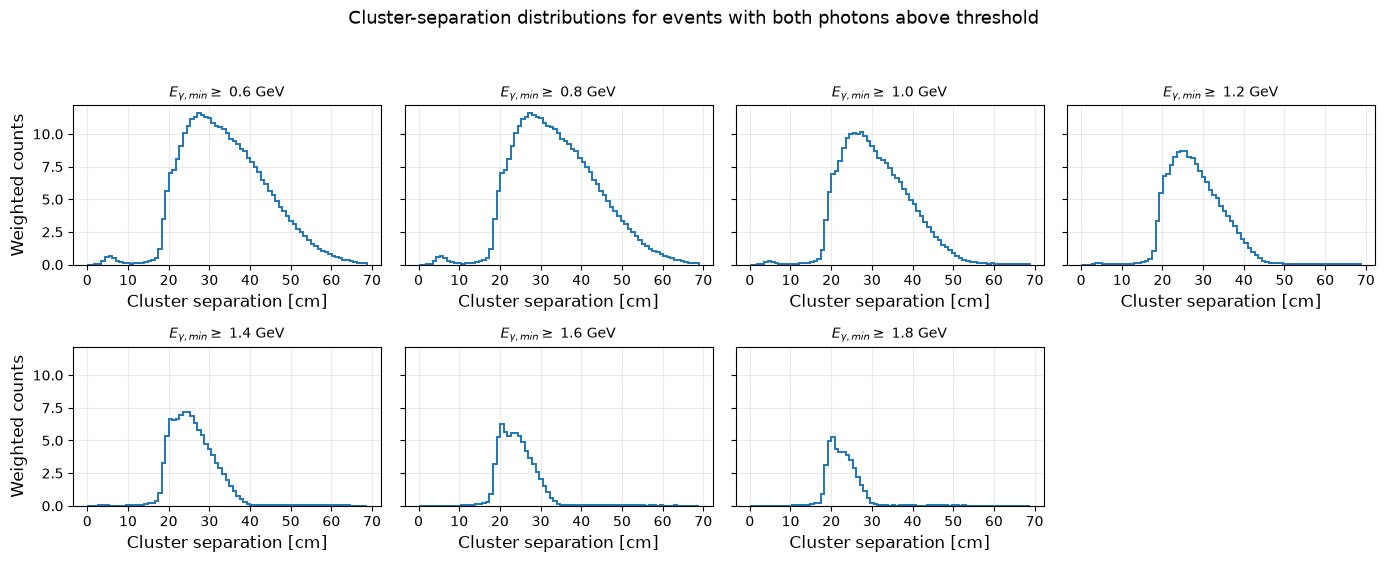

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

cluster_distance_rootfile = Path(
    "/w/hallc-scshelf2102/nps/singhav/nps_analysis/pi0_analysis/root_analysis_env_main/"
    "output/KinC_x36_5_yaopeng_08gev/KinC_x36_5/root/combined_branches_LH2_minus_3728_3729.root"
)
tree_name = "physics"
distance_branches = [
    "cluster_x_1",
    "cluster_y_1",
    "cluster_x_2",
    "cluster_y_2",
    "cluster_e_1",
    "cluster_e_2",
    "pi0_weight",
    "scale",
    "charge_uC",
    "run_number",
]

with uproot.open(cluster_distance_rootfile) as infile:
    arrays = infile[tree_name].arrays(distance_branches, library="np")

cluster_x_1 = arrays["cluster_x_1"].astype(float)
cluster_y_1 = arrays["cluster_y_1"].astype(float)
cluster_x_2 = arrays["cluster_x_2"].astype(float)
cluster_y_2 = arrays["cluster_y_2"].astype(float)
cluster_e_1 = arrays["cluster_e_1"].astype(float)
cluster_e_2 = arrays["cluster_e_2"].astype(float)
pi0_weight = arrays["pi0_weight"].astype(float)
scale = arrays["scale"].astype(float)
charge_uC = arrays["charge_uC"].astype(float)
run_number = arrays["run_number"]

# Match the data weighting used elsewhere: pi0_weight * scale * charge_frac.
# charge_frac is charge_uC / total_charge_uC, with charge counted once per run.
positive_charge = np.isfinite(charge_uC) & (charge_uC > 0)
unique_runs, first_seen = np.unique(run_number[positive_charge], return_index=True)
run_charge = charge_uC[positive_charge][first_seen]
total_charge_uC = run_charge.sum()
if not np.isfinite(total_charge_uC) or total_charge_uC <= 0:
    raise ValueError("Invalid total charge; cannot compute charge_frac weights")

charge_frac = np.zeros_like(charge_uC, dtype=float)
run_lookup = np.searchsorted(unique_runs, run_number)
has_charge = run_lookup < unique_runs.size
has_charge[has_charge] &= unique_runs[run_lookup[has_charge]] == run_number[has_charge]
charge_frac[has_charge] = run_charge[run_lookup[has_charge]] / total_charge_uC

cluster_distance = np.hypot(cluster_x_1 - cluster_x_2, cluster_y_1 - cluster_y_2)
min_photon_energy = np.minimum(cluster_e_1, cluster_e_2)
distance_weight = pi0_weight * scale * charge_frac
valid_distance = (
    np.isfinite(cluster_distance)
    & np.isfinite(min_photon_energy)
    & np.isfinite(distance_weight)
    & (distance_weight > 0)
)
cluster_distance = cluster_distance[valid_distance]
min_photon_energy = min_photon_energy[valid_distance]
distance_weight = distance_weight[valid_distance]

def weighted_quantile(values, weights, quantiles):
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumulative = np.cumsum(weights)
    if cumulative[-1] <= 0:
        raise ValueError("Cannot compute weighted quantiles with nonpositive total weight")
    return np.interp(np.asarray(quantiles) * cumulative[-1], cumulative, values)

energy_thresholds = np.round(np.arange(0.6, 1.8 + 0.05, 0.2), 1)
distance_bins = np.linspace(0.0, np.nanpercentile(cluster_distance, 99.5), 80)
distance_xticks = np.arange(0.0, distance_bins[-1] + 10.0, 10.0)

summary_rows = []
fig, axes = plt.subplots(4, 4, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.ravel()

for ax, threshold in zip(axes_flat, energy_thresholds):
    selected = min_photon_energy >= threshold
    selected_distance = cluster_distance[selected]
    selected_weight = distance_weight[selected]

    if selected_distance.size:
        ax.hist(
            selected_distance,
            bins=distance_bins,
            weights=selected_weight,
            histtype="step",
            linewidth=1.4,
        )
        q50 = weighted_quantile(selected_distance, selected_weight, [0.50])[0]
        weighted_mean = np.average(selected_distance, weights=selected_weight)
        summary_rows.append(
            {
                "min_photon_energy_cut_GeV": threshold,
                "entries": selected_distance.size,
                "sum_weight": selected_weight.sum(),
                "weighted_mean_cm": weighted_mean,
                "weighted_median_cm": q50,
            }
        )
    else:
        summary_rows.append(
            {
                "min_photon_energy_cut_GeV": threshold,
                "entries": 0,
                "sum_weight": 0.0,
                "weighted_mean_cm": np.nan,
                "weighted_median_cm": np.nan,
            }
        )

    ax.set_title(f"$E_{{\gamma,min}} \geq$ {threshold:.1f} GeV", fontsize=10)
    ax.grid(True, alpha=0.25)

for ax in axes_flat[len(energy_thresholds):]:
    ax.set_visible(False)

for ax in axes_flat[:len(energy_thresholds)]:
    ax.set_xlabel("Cluster separation [cm]")
    ax.set_xticks(distance_xticks)
    ax.tick_params(axis="x", labelbottom=True)
for ax in axes[:, 0]:
    ax.set_ylabel("Weighted counts")

fig.suptitle(
    "Cluster-separation distributions for events with both photons above threshold",
    y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))

distance_threshold_summary = pd.DataFrame(summary_rows)
distance_threshold_summary
